# Atrasando a entrada


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../DataSpline.csv")
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data["thetaLag"] = data["theta(Wd,We)"].shift(1)
data = data.iloc[1:]

In [2]:
import matplotlib.pyplot as plt

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)", "thetaLag"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo (sem interpolação)
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", linestyle="None", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 markersize=5)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito (sem interpolação)
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="o", linestyle="None", label=target,
                     color=target_colors[i % len(target_colors)],
                     markersize=5)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()


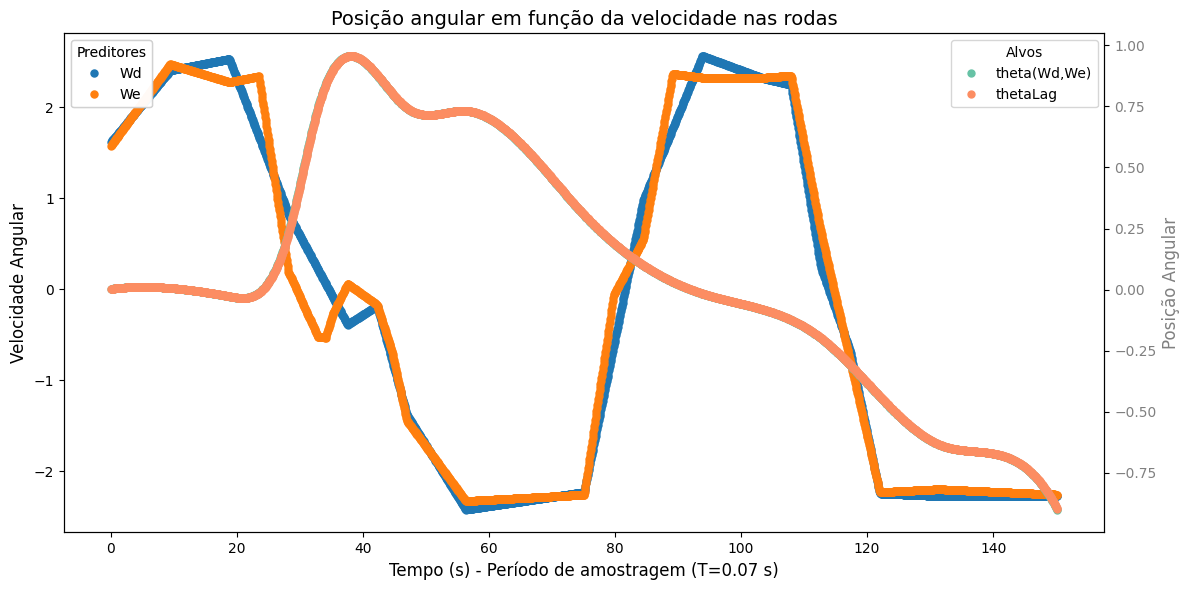

In [3]:
PlotTimeSeries(data)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We", "thetaLag"]
TARGET = "theta(Wd,We)"
VARIOGRAMS = ["gaussian", "spherical", "exponential", "power", "linear", "hole-effect"]

class Kriging3D:
    
    def __init__(self, Dataset):        

        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        self.train_samples_x = np.array(train_data[PREDICTORS])
        self.train_samples_y = np.array(train_data[TARGET])
        
        self.test_samples_x = np.array(test_data[PREDICTORS])
        self.test_samples_y = np.array(test_data[TARGET])
        
        self.train_time = Dataset.head(np.size(self.train_samples_y)).index
        self.test_time = Dataset.tail(np.size(self.test_samples_y)).index

        self.kriging_model = None

        
    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging3D(
            self.train_samples_x[:, 0], 
            self.train_samples_x[:, 1], 
            self.train_samples_x[:, 2], 
            self.train_samples_y, 
            variogram_model=VariogramType
        )
    
    def ComputeMetrics(self):
        self.train_pred = self.kriging_model.execute('points',
                                             self.train_samples_x[:, 0],
                                             self.train_samples_x[:, 1],
                                             self.train_samples_x[:, 2])[0]
        
        self.test_pred = self.kriging_model.execute('points',
                                             self.test_samples_x[:, 0],
                                             self.test_samples_x[:, 1],
                                             self.test_samples_x[:, 2])[0]
        

        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
            })
        
    
    def PlotOut(self, variogram):
        # Cores diferentes para cada linha
        colors = plt.cm.tab10.colors  # Paleta com 10 cores distintas

        # Criação da figura com dois subplots lado a lado
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        # Plot Treinamento
        ax1.plot(self.train_time, self.train_pred, marker="o", linewidth=2,
                label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.train_samples_y, marker="o", linewidth=2,
                label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()
        ax1.grid(True)

        # Plot Teste
        ax2.plot(self.test_time, self.test_pred, marker="o", linewidth=2,
                label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.test_samples_y, marker="o", linewidth=2,
                label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()
        ax2.grid(True)

        # Título geral
        fig.suptitle(f"Resultados do modelo Kriging 2D: {variogram}", fontsize=15)

        # Salvando a figura
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta espaço para o suptitle
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)

        # Exibe o gráfico
        plt.show()
                    
    
    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model
                
                display(metrics)
                df = pd.DataFrame([metrics])  
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)

{'r2_training': 1.0,
 'mse_training': 1.1328272065697138e-25,
 'mape_training': 2.3428055543551485e-11,
 'rmse_training': 3.365749851919649e-13,
 'r2_test': -0.5409407984114138,
 'mse_test': 0.046757445225654976,
 'mape_test': 0.32018564731092747,
 'rmse_test': 0.2162346994024201}

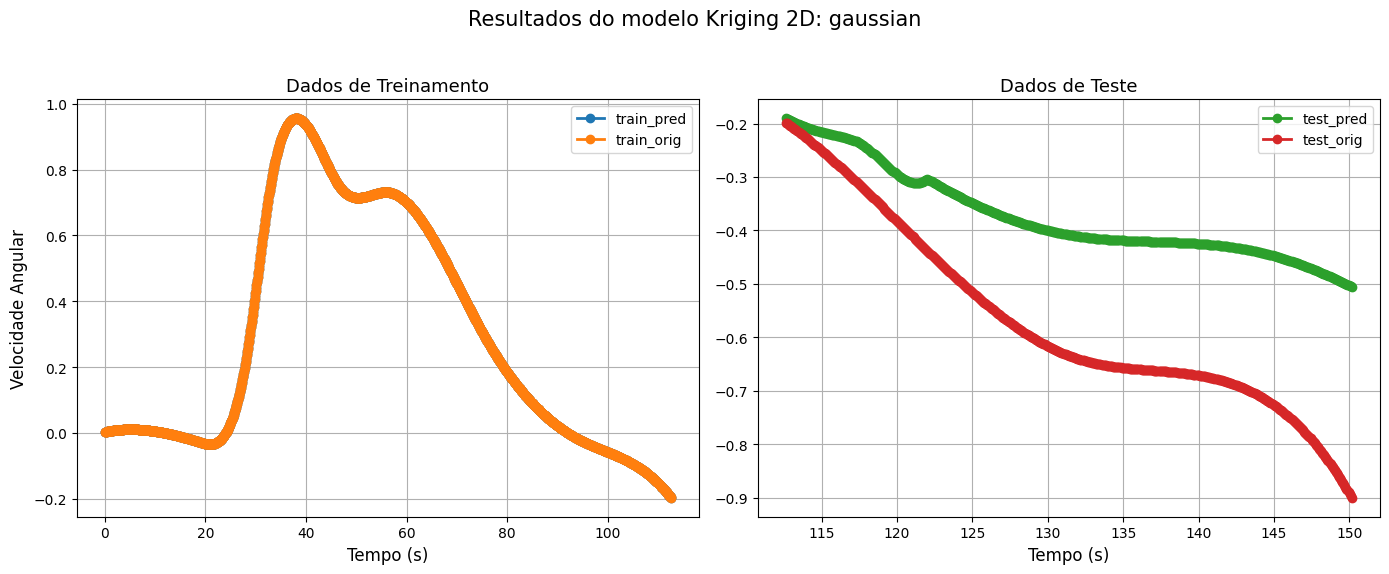

{'r2_training': 1.0,
 'mse_training': 2.9818249127735894e-24,
 'mape_training': 1.1621286621292626e-10,
 'rmse_training': 1.7267961410582285e-12,
 'r2_test': -11.593850826491549,
 'mse_test': 0.38214076154438364,
 'mape_test': 1.0044927755382296,
 'rmse_test': 0.6181753485414827}

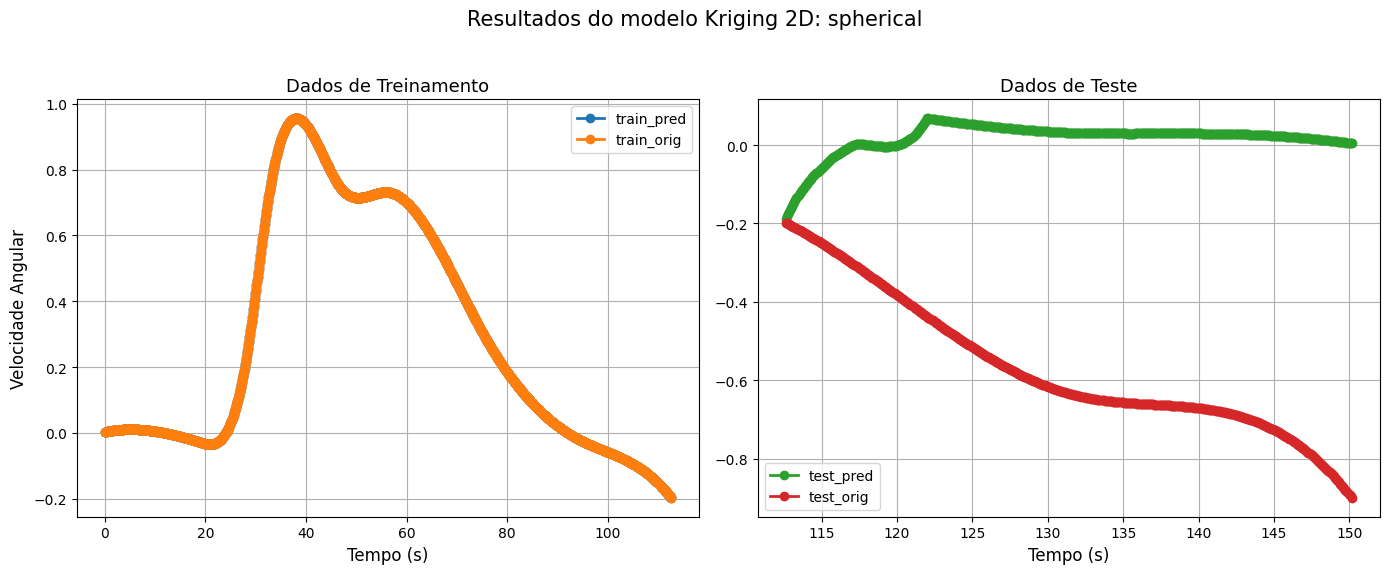

{'r2_training': 1.0,
 'mse_training': 1.8286321660979405e-24,
 'mape_training': 1.1830699032341075e-10,
 'rmse_training': 1.3522692653824312e-12,
 'r2_test': -16.327902582385992,
 'mse_test': 0.5257881786935995,
 'mape_test': 1.197639999988752,
 'rmse_test': 0.7251125282972288}

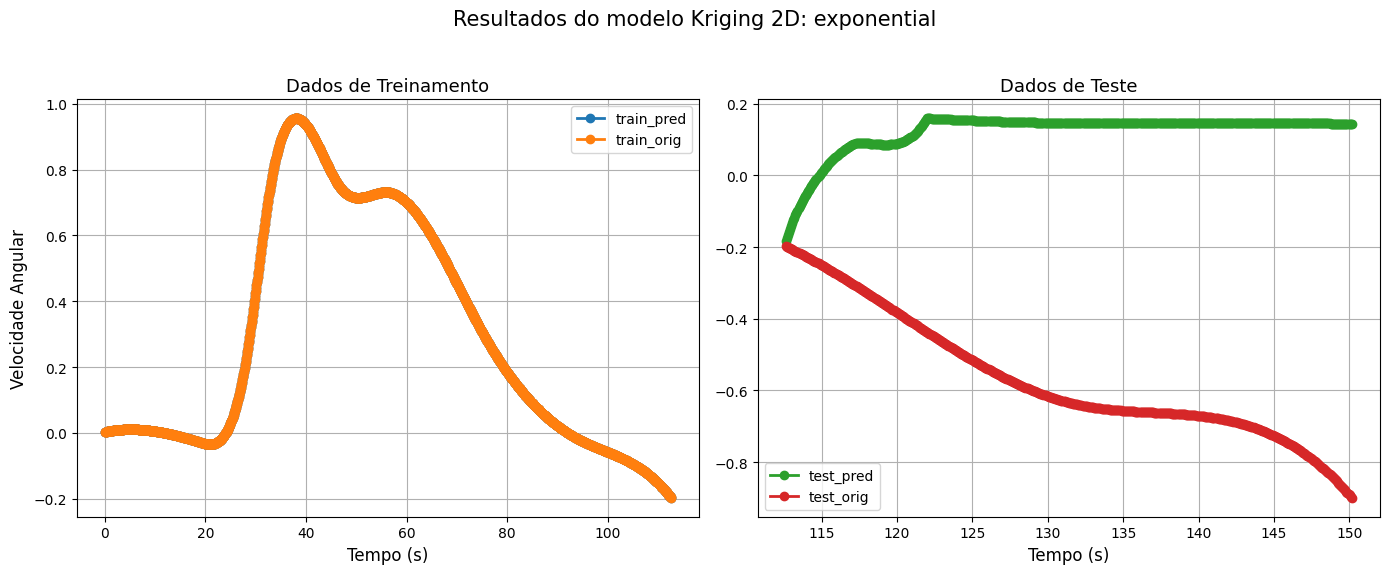

{'r2_training': 1.0,
 'mse_training': 1.240930890471205e-25,
 'mape_training': 1.2204728475682452e-11,
 'rmse_training': 3.522684900003412e-13,
 'r2_test': -16.3483569433669,
 'mse_test': 0.5264088343762685,
 'mape_test': 1.2072919863966325,
 'rmse_test': 0.725540374049762}

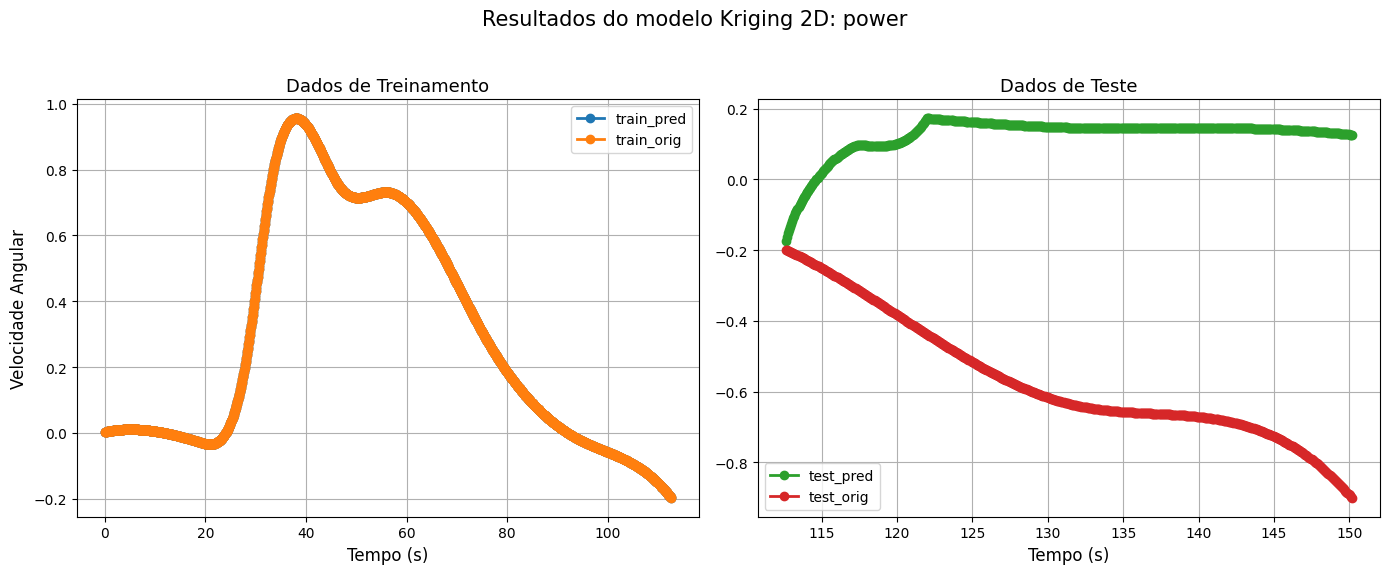

{'r2_training': 1.0,
 'mse_training': 7.038661019646193e-27,
 'mape_training': 6.56401129592957e-13,
 'rmse_training': 8.389672830120489e-14,
 'r2_test': -10.456271196807561,
 'mse_test': 0.34762268188836776,
 'mape_test': 0.9709458212264445,
 'rmse_test': 0.5895953543646419}

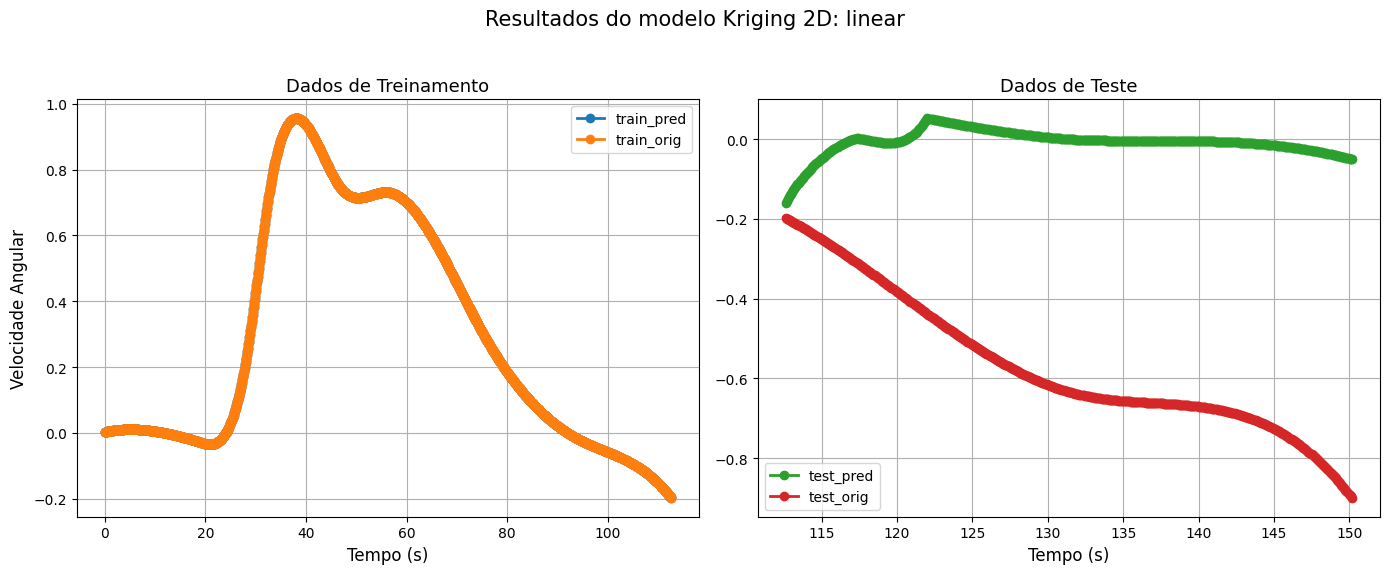

{'r2_training': 1.0,
 'mse_training': 4.39687685260468e-25,
 'mape_training': 4.139543496660503e-11,
 'rmse_training': 6.630895001886759e-13,
 'r2_test': -18.022085850512287,
 'mse_test': 0.5771955276607379,
 'mape_test': 1.271122173868237,
 'rmse_test': 0.7597338531753984}

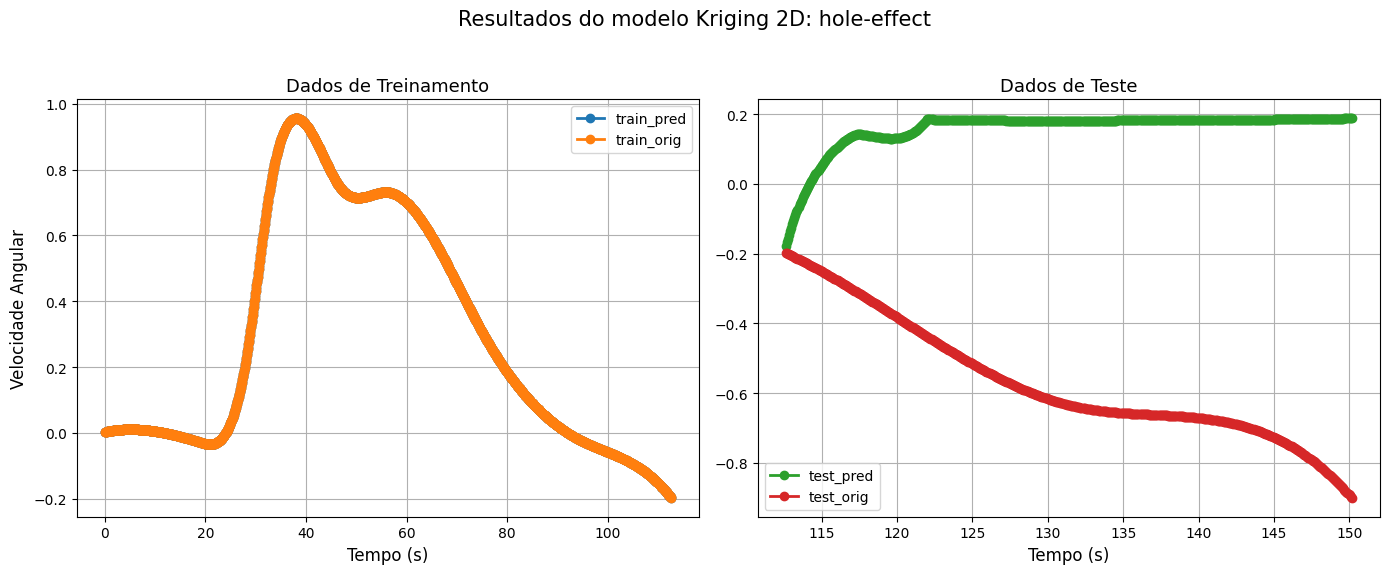

In [5]:
Vsg = Kriging3D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")